## Miscellanea

Check how the topN are performing

In [ ]:
gI.topN_overlap_tot_rel_err(g)

In [ ]:
cutoff = len(gI._topN_nodes)

for i in range(cutoff):
    print(f'\n-i: {i+1}',)
    gI_nodes, g_nodes = gI._topN_nodes[i], g._topN_nodes[i]
    print(f'-gI_nodes: {gI_nodes}',)
    print(f'-g_nodes, len: {g_nodes, len(g_nodes)}',)
    inters = np.intersect1d(gI_nodes, g_nodes)
    diff = np.setdiff1d(gI_nodes, g_nodes, assume_unique=True)
    print(f'-inters, len: {inters, inters.size}',)
    print(f'-diff: {diff}',)
    print(f'-gI._topN_overlap[i]: {gI._topN_overlap[i]}',)


-i: 1
-gI_nodes: [69]
-g_nodes, len: (array([69]), 1)
-inters, len: (array([69]), 1)
-diff: []
-gI._topN_overlap[i]: 1.0

-i: 2
-gI_nodes: [ 69 102]
-g_nodes, len: (array([ 69, 102]), 2)
-inters, len: (array([ 69, 102]), 2)
-diff: []
-gI._topN_overlap[i]: 1.0

-i: 3
-gI_nodes: [ 69 102  18]
-g_nodes, len: (array([ 69, 102,  18]), 3)
-inters, len: (array([ 18,  69, 102]), 3)
-diff: []
-gI._topN_overlap[i]: 1.0

-i: 4
-gI_nodes: [ 69 102  18  15]
-g_nodes, len: (array([ 69, 102,  18,  15]), 4)
-inters, len: (array([ 15,  18,  69, 102]), 4)
-diff: []
-gI._topN_overlap[i]: 1.0

-i: 5
-gI_nodes: [ 69 102  18  15  61]
-g_nodes, len: (array([ 69, 102,  18,  15,  61]), 5)
-inters, len: (array([ 15,  18,  61,  69, 102]), 5)
-diff: []
-gI._topN_overlap[i]: 1.0

-i: 6
-gI_nodes: [ 69 102  18  15  61 135]
-g_nodes, len: (array([ 69, 102,  18,  15,  61, 148]), 6)
-inters, len: (array([ 15,  18,  61,  69, 102]), 5)
-diff: [135]
-gI._topN_overlap[i]: 0.8333333333333334

-i: 7
-gI_nodes: [ 69 102  18

Evaluating the g deg with the good-old matrix formulation

-abs_diff_num_edges: 2.902974301832728e-05
-abs_diff_out_deg: 5.80528876525932e-07
-abs_diff_in_deg: 8.927844987738354e-07


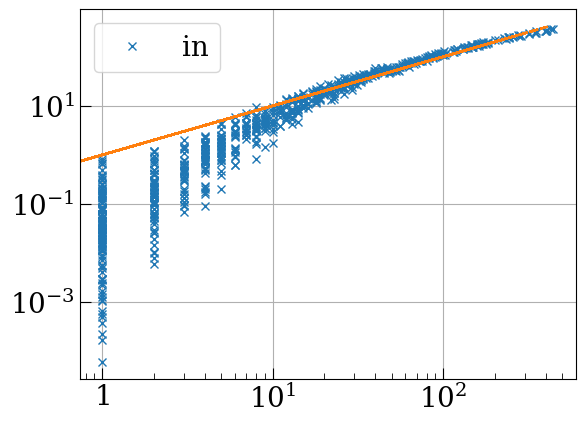

In [ ]:
# matrix evaluation
prop_out, prop_in = model.prop_out[:, None], model.prop_in[None, :]
arg = model.param[0] * prop_out @ prop_in
frmv_diag = lambda A: A * (1 - np.eye(A.shape[0]))
P = frmv_diag(-np.expm1(-arg))
out_deg = P.sum(1)
in_deg = P.sum(0)
# print(f'-P:\n {P}',)

abs_diff_num_edges = abs(P.sum() - model.expected_num_edges())
abs_diff_out_deg = np.max(np.abs(model._out_degree - out_deg))
abs_diff_in_deg = np.max(np.abs(model._in_degree - in_deg))

print(f'-abs_diff_num_edges: {abs_diff_num_edges}',)
print(f'-abs_diff_out_deg: {abs_diff_out_deg}',)
print(f'-abs_diff_in_deg: {abs_diff_in_deg}',)

# plt.plot(g._out_degree, out_deg, "x", label = "out")
# plt.plot(g._in_degree, in_deg, "x", label = "in")
# plt.plot(g._out_degree, g._out_degree, "--")
# plt.legend()
# plt.xscale("log")
# plt.yscale("log")

Comparison of new code to calculate the function and jacobian

In [ ]:
omodel = sp.ScaleInvariantModel(gI, **kwargs_model)
omodel.param = [0.3]
omodel.num_edges_fit_fun(omodel.param)

omodel = sp.ScaleInvariantModel(gI, **kwargs_model)
# omodel.prop_out = np.arange(3)
# omodel.prop_in = np.arange(3)
omodel.param = [0.3]
omod_ne, omod_jac = omodel.num_edges_fit_fun(omodel.param)
omod_ne, omod_jac

frmv_diag = lambda A: A * (1 - np.eye(A.shape[0]))

prop_out, prop_in = omodel.prop_out[:, None], omodel.prop_in[None, :]
arg = omodel.param * prop_out @ prop_in
P = frmv_diag(-np.expm1(-arg))
# print(f'-P:\n {P}',)
P.sum()

(2413.162882249104, 46.362625047975285)

np.float64(2413.1628822491048)

### Check if num edges with frozen edges is correct

Compare matrix calculation (numpy) with discarding frozen edges in the for-loop (numba)

In [ ]:
frmv_diag = lambda A: A * (1 - np.eye(A.shape[0]))

# def the argument of the MSM p_ij
arg = model.param * model.prop_out[:, None] @ model.prop_in[None, :]

# compute the p_ij
p_ij = -np.expm1(-arg)
print(f'-p_ij.shape: {p_ij.shape}',)

# mask not to sample the internal nodes
unsampled_ij = ~(unsampled_vI[:, None] @ unsampled_vI[None, :]).astype(bool)
print(f'-unsampled_ij.shape: {unsampled_ij.shape}',)

# filter the off-diagonal and not-frozen edges
unsampled_pij = frmv_diag(p_ij)[unsampled_ij]

# find their sum, i.e. off-diagonal and not-frozen number of edges
num_edges_matrix = unsampled_pij.sum()
print(f'-num_edges_matrix: {num_edges_matrix}',)

# check if its the same with the one computed internally
num_edges_matrix += gI._num_edges
model.expected_num_edges(recompute = True, unsampled_vI = unsampled_vI, num_frozen_edges = gI._num_edges)

utils.signed_rel_err(num_edges_matrix, model._exp_num_edges)

### Compute observed Page-Ranks on the splitted networks

In [ ]:
# from os.path import dirname as up

# gI_dirfunc = lambda intra_size, vsplit: up(up(g.vars_dir)) + f"/intra_size{intra_size}/vsplit{vsplit}/level{g.level}"

# for intra_size in intra_sizes:
# 	for vsplit in range(num_vsplits):
        
# 		# vsplit nodes, edges in interal
# 		if not os.path.exists(gI_dirfunc(intra_size, vsplit)):
# 			vI, eI = g.vsplit_intra_row(v, e, intra_size=intra_size, vsplit=vsplit)

# 			# update the graph name
# 			kwargs_graph.update({'graph_kind': "intra", "intra_size" : intra_size, "vsplit" : vsplit})
# 			gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)

# 			# compute the page-rank only in the internal part
# 			gI.page_rank = gI.pagerank_power(**g._kwargs_pr)

# 			gI.save_vars()
            
# plot.pagerank_on_internal_nodes(g, gI_dirfunc, intra_size, num_vsplits,)

### Sampling with GPUs in Torch or CPUs with numba

Check if `unsampled_vI` entries are fixed

In [ ]:
import numpy as np
from itertools import product

# select the unsampled_vI
uns_id = np.where(unsampled_vI)[0]

# create a mapping from node to id
matidx_2_id = {k:v for k,v in enumerate(uns_id)}

# create a meshgrid
rows, cols = np.array(list(product(uns_id, repeat=2))).T
uns_N = len(uns_id)
print(f'-uns_N: {uns_N}',)

# filter the gs.adj for all the uns_id pairs
mat = gs.adj[rows, cols].reshape(uns_N, uns_N)

# find where mat is true
mat_rows, mat_cols = np.where(mat)

# create the DataFrame mapped into full-id nodes
frozen_edges_mat = pd.DataFrame({"_src" : mat_rows, "_dst" : mat_cols}).map(matidx_2_id.get)

# check the edges are the same
frozen_edges_mat.eq(frozen_edges).all()

-uns_N: 15


np.True_

Do Page-Rank for `gU`

In [ ]:
# find idx of edges containing v and filter edges
idx_at_least_one_ = lambda vI: e['src'].isin(vI['id']) | e['dst'].isin(vI['id'])

# containing vI, vR
idx_eU = idx_at_least_one_(vI)

# select the edge ING
eU = 3
# eU = edge_idx(idx_eU)

# reselect vU, since using v leads to inactive nodes not well-handled by the DiGraph
vU = unique_nodes_from(eU.iloc[:,:2])

In [ ]:
# kwargs_graph.update({'intra_size' : intra_size, 'vsplit' : vsplit, 'graph_kind' : "intra_inter",})
gU = sp.graphs.DiGraph(vU, eU, **kwargs_graph)
# g.load_or_create_degrees()

Compare the United PageRank vs Full PageRank over all the `vU` 

In [ ]:
pr_gU = pagerank_power(gU.adj, p=0.85, max_iter=100,
                   tol=1e-06, personalize=None, reverse=True)

In [ ]:
idx_IntraNode2United = list(map(lambda x: gU.id_dict.get(x), gI.id_dict))
pr_gU_on_Intra = pr_gU[idx_IntraNode2United]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([pr_g_on_I.min(), pr_g_on_I.max()],
        [pr_g_on_I.min(), pr_g_on_I.max()],
        'r--')

ms, alpha = 30, 0.6
ax.scatter(pr_g_on_I, pr_gI, alpha=alpha, label = f"Intra PR", marker = 'o', c = dep.obs_color, s = ms)
ax.scatter(pr_g_on_I, pr_gU_on_Intra, alpha=alpha, label = f"United PR", marker = 'x', c = dep.ref_model_color, s = ms)
ax.set(
    xlabel='Full-PR on Intra',
    ylabel='Intra/United',
    title='PageRank: Intra/United VS Full',
    xscale='log',
    yscale='log'
)
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([60])
ax.grid(False)

utils.save_fig(fig, full_path = g.plots_base_dir + "/PageRanks_on_Intra.png")
plt.close()

[Text(0.5, 0, 'Full-PR on Intra'),
 Text(0, 0.5, 'Intra/United'),
 Text(0.5, 1.0, 'PageRank: Intra/United VS Full'),
 None,
 None]